In [1]:
!pip install pyspark

Spark Session Created Successfully
Dataset Loaded Successfully
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|  Customer Name|  Segment|      Country|           City|     State|Postal Code|Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|  Profit|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|     1|CA-2016-152156| 11/8/2016|11/11/2016|  Second Class|   CG-12520|    Claire Gute| Consumer|United States|      Henderson|  Kentucky|      42420| So

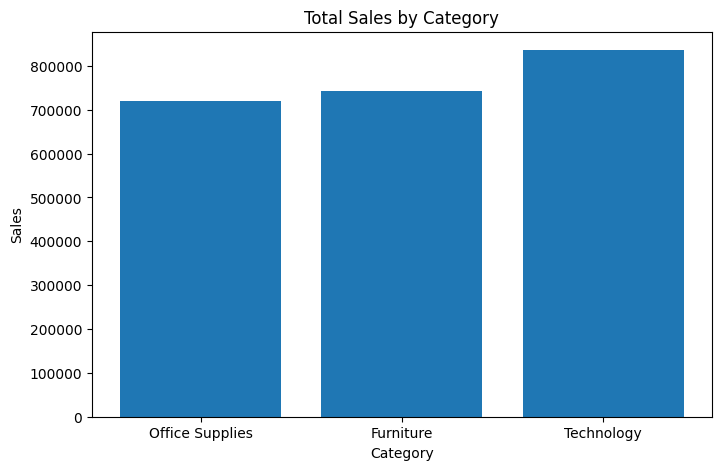

In [11]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, avg
import pandas as pd
import matplotlib.pyplot as plt

# Create Spark Session
spark = SparkSession.builder \
    .appName("Big Data Analysis") \
    .getOrCreate()

print("Spark Session Created Successfully")

# Load Dataset
pandas_df = pd.read_csv("/srv/superstore.csv", encoding='latin1')

# Convert to Spark DataFrame
sales_df = spark.createDataFrame(pandas_df)

print("Dataset Loaded Successfully")

# Show Dataset
sales_df.show(5)

# Print Schema
sales_df.printSchema()

# Count Rows
print("Total Rows:", sales_df.count())

# Remove Duplicates
sales_df = sales_df.dropDuplicates()

# Category Sales
category_sales = sales_df.groupBy("Category") \
    .agg(sum("Sales").alias("Total_Sales"))

category_sales.show()

# Region Sales
region_sales = sales_df.groupBy("Region") \
    .agg(sum("Sales").alias("Total_Sales"))

region_sales.show()

# Convert for plotting
category_sales_pd = category_sales.toPandas()

# Plot
plt.figure(figsize=(8,5))
plt.bar(category_sales_pd['Category'],
        category_sales_pd['Total_Sales'])

plt.xlabel("Category")
plt.ylabel("Sales")
plt.title("Total Sales by Category")
plt.show()

spark.stop()